In [1]:
!pip -q install ultralytics opencv-python pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.8 MB/s eta 0:00:00


In [2]:
import random
import shutil
from pathlib import Path

In [3]:
# Dataset gốc đang train
SRC_DATASET_DIR = Path("/kaggle/input/datasets/colnguyen/rubbish-dataset-segmentation-1000-pics")

# Dataset not_rubbish
NOT_RUBBISH_DIR = Path("/kaggle/input/datasets/colnguyen/not-rubbish-test/not_rubbish2")

# Dataset mới để train trong /kaggle/working
WORK_DATASET_DIR = Path("/kaggle/working/rubbish_dataset")

In [4]:
if WORK_DATASET_DIR.exists():
    shutil.rmtree(WORK_DATASET_DIR)

shutil.copytree(SRC_DATASET_DIR, WORK_DATASET_DIR)

print("Copied dataset to:", WORK_DATASET_DIR)

Copied dataset to: /kaggle/working/rubbish_dataset


In [5]:
TRAIN_IMG_DIR = WORK_DATASET_DIR / "train" / "images"
TRAIN_LBL_DIR = WORK_DATASET_DIR / "train" / "labels"

print("Train image dir:", TRAIN_IMG_DIR)
print("Train label dir:", TRAIN_LBL_DIR)
print("Images exists:", TRAIN_IMG_DIR.exists())
print("Labels exists:", TRAIN_LBL_DIR.exists())

Train image dir: /kaggle/working/rubbish_dataset/train/images
Train label dir: /kaggle/working/rubbish_dataset/train/labels
Images exists: True
Labels exists: True


In [6]:
def get_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return [p for p in Path(folder).rglob("*") if p.suffix.lower() in exts]

before_imgs = get_images(TRAIN_IMG_DIR)

print("Train images before:", len(before_imgs))

Train images before: 692


In [7]:
all_not_rubbish = get_images(NOT_RUBBISH_DIR)

print("Total not_rubbish images found:", len(all_not_rubbish))

random.seed(42)  # để lần nào chạy cũng reproducible
num_samples = 500

selected_images = random.sample(all_not_rubbish, min(num_samples, len(all_not_rubbish)))

print("Selected images:", len(selected_images))
for p in selected_images[:5]:
    print(p.name)

Total not_rubbish images found: 2000
Selected images: 500
91343852333181587501617224946968450901931364505-2.jpg
91343852333182050050485263693500584670337151076-2.jpg
3TsEG2euKkkik2OMv1GniQ.jpg
2022-04-25T06.28.30.frame31.jpg
91343852333183269832420052835722896107610695528-2.jpg


In [8]:
copied_count = 0

for i, img_path in enumerate(selected_images):
    # thêm prefix để tránh trùng tên file
    new_img_name = f"not_rubbish_{i:04d}{img_path.suffix.lower()}"
    new_lbl_name = f"not_rubbish_{i:04d}.txt"

    dst_img_path = TRAIN_IMG_DIR / new_img_name
    dst_lbl_path = TRAIN_LBL_DIR / new_lbl_name

    shutil.copy2(img_path, dst_img_path)

    # tạo label rỗng cho ảnh không có rác
    with open(dst_lbl_path, "w") as f:
        pass

    copied_count += 1

print(f"Done. Copied {copied_count} images and created {copied_count} empty label files.")

Done. Copied 500 images and created 500 empty label files.


In [9]:
after_imgs = get_images(TRAIN_IMG_DIR)
after_lbls = list(TRAIN_LBL_DIR.glob("*.txt"))

print("Train images after :", len(after_imgs))
print("Train labels after :", len(after_lbls))
print("Added images       :", len(after_imgs) - len(before_imgs))

Train images after : 1192
Train labels after : 1192
Added images       : 500


In [10]:
new_imgs = sorted([p.name for p in TRAIN_IMG_DIR.glob("not_rubbish_*")])[:10]
new_lbls = sorted([p.name for p in TRAIN_LBL_DIR.glob("not_rubbish_*")])[:10]

print("Sample added images:")
for x in new_imgs:
    print(x)

print("\nSample added labels:")
for x in new_lbls:
    print(x)

Sample added images:
not_rubbish_0000.jpg
not_rubbish_0001.jpg
not_rubbish_0002.jpg
not_rubbish_0003.jpg
not_rubbish_0004.jpg
not_rubbish_0005.jpg
not_rubbish_0006.jpg
not_rubbish_0007.jpg
not_rubbish_0008.jpg
not_rubbish_0009.jpg

Sample added labels:
not_rubbish_0000.txt
not_rubbish_0001.txt
not_rubbish_0002.txt
not_rubbish_0003.txt
not_rubbish_0004.txt
not_rubbish_0005.txt
not_rubbish_0006.txt
not_rubbish_0007.txt
not_rubbish_0008.txt
not_rubbish_0009.txt


In [11]:
import yaml

yaml_data = {
    "path": str(WORK_DATASET_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {
        0: "rubbish_area"
    }
}

NEW_YAML_PATH = WORK_DATASET_DIR / "data_working.yaml"

with open(NEW_YAML_PATH, "w") as f:
    yaml.dump(yaml_data, f, sort_keys=False)

print("New YAML saved at:", NEW_YAML_PATH)

with open(NEW_YAML_PATH, "r") as f:
    print(f.read())

New YAML saved at: /kaggle/working/rubbish_dataset/data_working.yaml
path: /kaggle/working/rubbish_dataset
train: train/images
val: valid/images
test: test/images
names:
  0: rubbish_area



In [12]:
from ultralytics import YOLO

model = YOLO("yolo26s-seg.pt")

results = model.train(
    data=str(NEW_YAML_PATH),
    epochs=80,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    pretrained=True,
    patience=20,
    project="/kaggle/working/seg_runs",
    name="rubbish_area_yolo26n_seg_with_not_rubbish",
    exist_ok=True,

    degrees=5.0,
    translate=0.05,
    scale=0.20,
    shear=0.0,
    perspective=0.0,
    fliplr=0.5,
    flipud=0.0,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/rubbish_dataset/data_working.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

In [13]:
best_model_path = "/kaggle/working/seg_runs/rubbish_area_yolo26n_seg_with_not_rubbish/weights/best.pt"

best_model = YOLO(best_model_path)
metrics = best_model.val(
    data=str(NEW_YAML_PATH),
    split="val"
)

print(metrics)

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-seg summary (fused): 139 layers, 10,365,727 parameters, 0 gradients, 34.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1541.5±591.7 MB/s, size: 60.0 KB)
val: Scanning /kaggle/working/rubbish_dataset/valid/labels.cache... 197 images, 50 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 197/197 75.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.2it/s 4.0s
                   all        197        291      0.774       0.55      0.632      0.435      0.781       0.55       0.63      0.442
Speed: 1.7ms preprocess, 11.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/segment/val
ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ul

In [14]:
pred_results = best_model.predict(
    source=str(WORK_DATASET_DIR / "valid" / "images"),
    conf=0.3,
    save=True,
    device=0
)

test_results = best_model.predict(
    source=str(WORK_DATASET_DIR / "test" / "images"),
    conf=0.3,
    save=True,
    device=0
)


image 1/197 /kaggle/working/rubbish_dataset/valid/images/11_jpg.rf.ef7a08afe2a565d65b38871c3b14cce4.jpg: 480x640 1 rubbish_area, 66.5ms
image 2/197 /kaggle/working/rubbish_dataset/valid/images/13_jpg.rf.66c4fae387ff42ab0f588d97835f475d.jpg: 480x640 1 rubbish_area, 17.5ms
image 3/197 /kaggle/working/rubbish_dataset/valid/images/2022-04-07T06-35-10-frame41_jpg.rf.579bc3620e0c558395bd18cd5b2f44c4.jpg: 480x640 (no detections), 17.5ms
image 4/197 /kaggle/working/rubbish_dataset/valid/images/2022-04-08T07-08-53-frame21-Copy_jpg.rf.88250581f8ab3ecab060ce2f4584b0c1.jpg: 480x640 (no detections), 17.4ms
image 5/197 /kaggle/working/rubbish_dataset/valid/images/2022-04-08T08-01-38-frame11_jpg.rf.a3faa639c83de6c360041b656b058c61.jpg: 480x640 (no detections), 17.5ms
image 6/197 /kaggle/working/rubbish_dataset/valid/images/2022-04-08T09-46-58-frame41_jpg.rf.27731f35592cde6763267f1c3301b788.jpg: 480x640 (no detections), 17.4ms
image 7/197 /kaggle/working/rubbish_dataset/valid/images/2022-04-08T09-47-

In [15]:
metrics = best_model.val(
    data=str(NEW_YAML_PATH),
    split="val"
)

# Detection metrics (box)
print("===== METRICS (BOX) =====")
print(f"Precision     : {metrics.box.mp:.4f}")
print(f"Recall        : {metrics.box.mr:.4f}")
print(f"mAP50         : {metrics.box.map50:.4f}")
print(f"mAP50-95      : {metrics.box.map:.4f}")

# Segmentation metrics (quan trọng hơn)
print("\n===== METRICS (SEGMENTATION) =====")
print(f"Precision     : {metrics.seg.mp:.4f}")
print(f"Recall        : {metrics.seg.mr:.4f}")
print(f"mAP50         : {metrics.seg.map50:.4f}")
print(f"mAP50-95      : {metrics.seg.map:.4f}")

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2007.1±627.9 MB/s, size: 79.4 KB)
val: Scanning /kaggle/working/rubbish_dataset/valid/labels.cache... 197 images, 50 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 197/197 41.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.2it/s 4.1s
                   all        197        291      0.774       0.55      0.632      0.435      0.781       0.55       0.63      0.442
Speed: 1.7ms preprocess, 10.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/segment/val2
===== METRICS (BOX) =====
Precision     : 0.7743
Recall        : 0.5498
mAP50         : 0.6318
mAP50-95      : 0.4353

===== METRICS (SEGMENTATION) =====
Precision     : 0.7805
Recall        : 0.5500
mAP50         : 0.6303
mAP50-95      : 0.4420


Confusion matrix: True
Normalized CM   : True


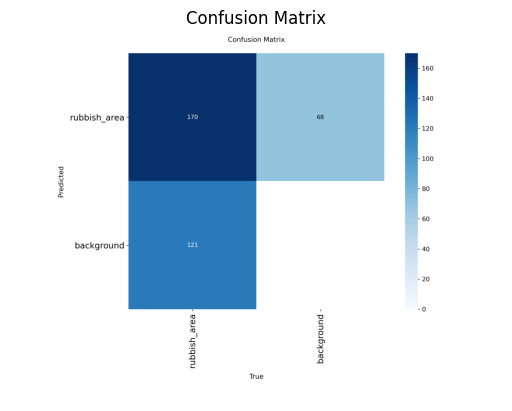

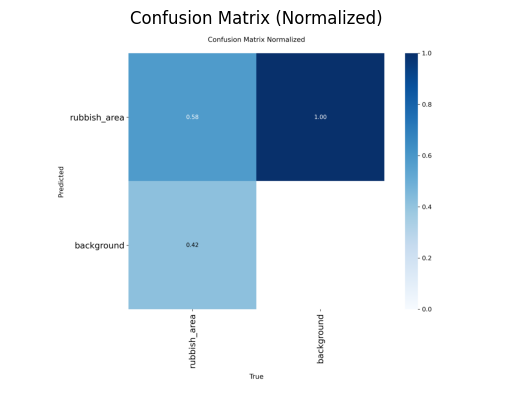

In [16]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

RUN_DIR = Path("/kaggle/working/seg_runs/rubbish_area_yolo26n_seg_with_not_rubbish")

# tìm file confusion matrix
cm_path = RUN_DIR / "confusion_matrix.png"
cm_norm_path = RUN_DIR / "confusion_matrix_normalized.png"

print("Confusion matrix:", cm_path.exists())
print("Normalized CM   :", cm_norm_path.exists())

if cm_path.exists():
    img = cv2.imread(str(cm_path))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Confusion Matrix")
    plt.axis("off")
    plt.show()

if cm_norm_path.exists():
    img = cv2.imread(str(cm_norm_path))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Confusion Matrix (Normalized)")
    plt.axis("off")
    plt.show()

In [17]:
import numpy as np

cm = metrics.confusion_matrix.matrix

print("Confusion Matrix (raw):")
print(cm)

# normalize theo hàng
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

print("\nConfusion Matrix (normalized):")
print(np.round(cm_norm, 3))

Confusion Matrix (raw):
[[        170          69]
 [        121           0]]

Confusion Matrix (normalized):
[[      0.711       0.289]
 [          1           0]]



0: 640x640 1 rubbish_area, 17.3ms
1: 640x640 4 rubbish_areas, 17.3ms
2: 640x640 (no detections), 17.3ms
3: 640x640 (no detections), 17.3ms
4: 640x640 1 rubbish_area, 17.3ms
5: 640x640 5 rubbish_areas, 17.3ms
Speed: 1.4ms preprocess, 17.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


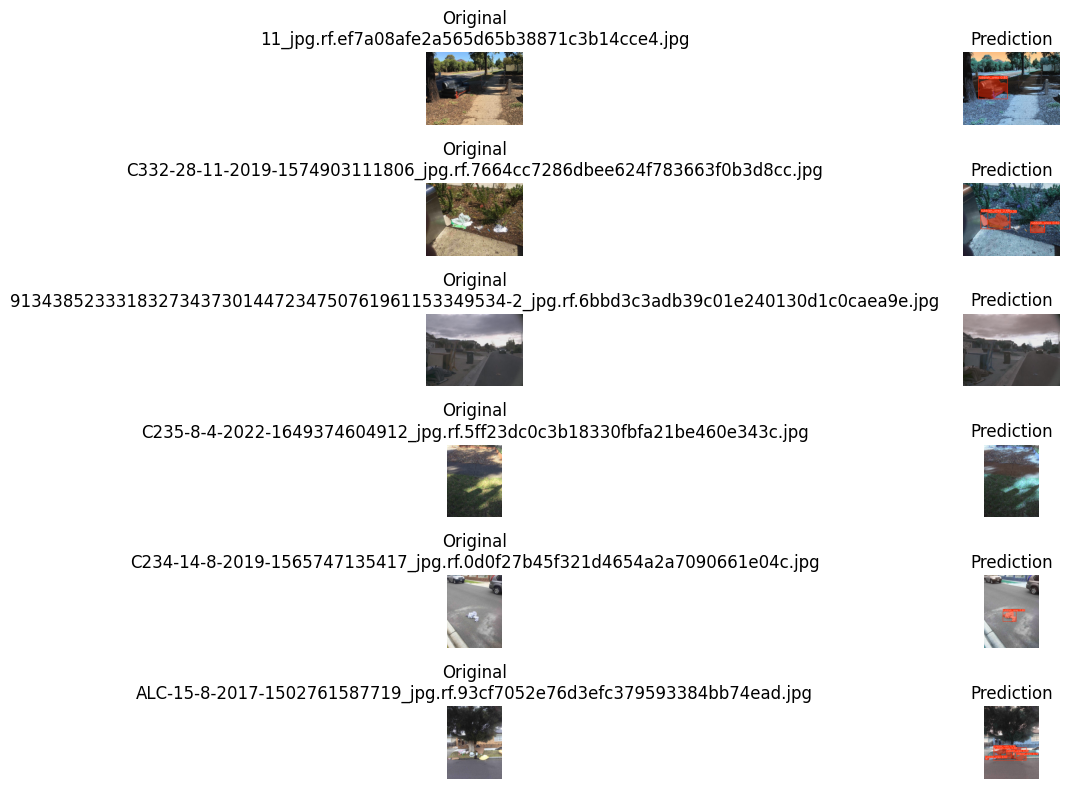

In [18]:
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# ====== CONFIG ======
IMG_DIR = WORK_DATASET_DIR / "valid" / "images"   # hoặc test/images
NUM_SAMPLES = 6                              # số ảnh muốn xem
CONF = 0.25

# ====== LOAD IMAGES ======
exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
all_images = [p for p in IMG_DIR.rglob("*") if p.suffix.lower() in exts]

sample_images = random.sample(all_images, min(NUM_SAMPLES, len(all_images)))

# ====== PREDICT ======
results = best_model.predict(
    source=[str(p) for p in sample_images],
    conf=CONF,
    save=False,
    device=0
)

# ====== PLOT ======
plt.figure(figsize=(15, 8))

for i, (img_path, res) in enumerate(zip(sample_images, results)):
    # ảnh gốc
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ảnh có prediction
    pred_img = res.plot()  # YOLO vẽ sẵn bbox + mask

    # show original
    plt.subplot(len(sample_images), 2, 2*i + 1)
    plt.imshow(img)
    plt.title(f"Original\n{img_path.name}")
    plt.axis("off")

    # show prediction
    plt.subplot(len(sample_images), 2, 2*i + 2)
    plt.imshow(pred_img)
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

No-rubbish images: 50

0: 640x480 (no detections), 13.7ms
1: 640x480 (no detections), 13.7ms
2: 640x480 (no detections), 13.7ms
3: 640x480 (no detections), 13.7ms
4: 640x480 (no detections), 13.7ms
5: 640x480 (no detections), 13.7ms
Speed: 1.5ms preprocess, 13.7ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 480)


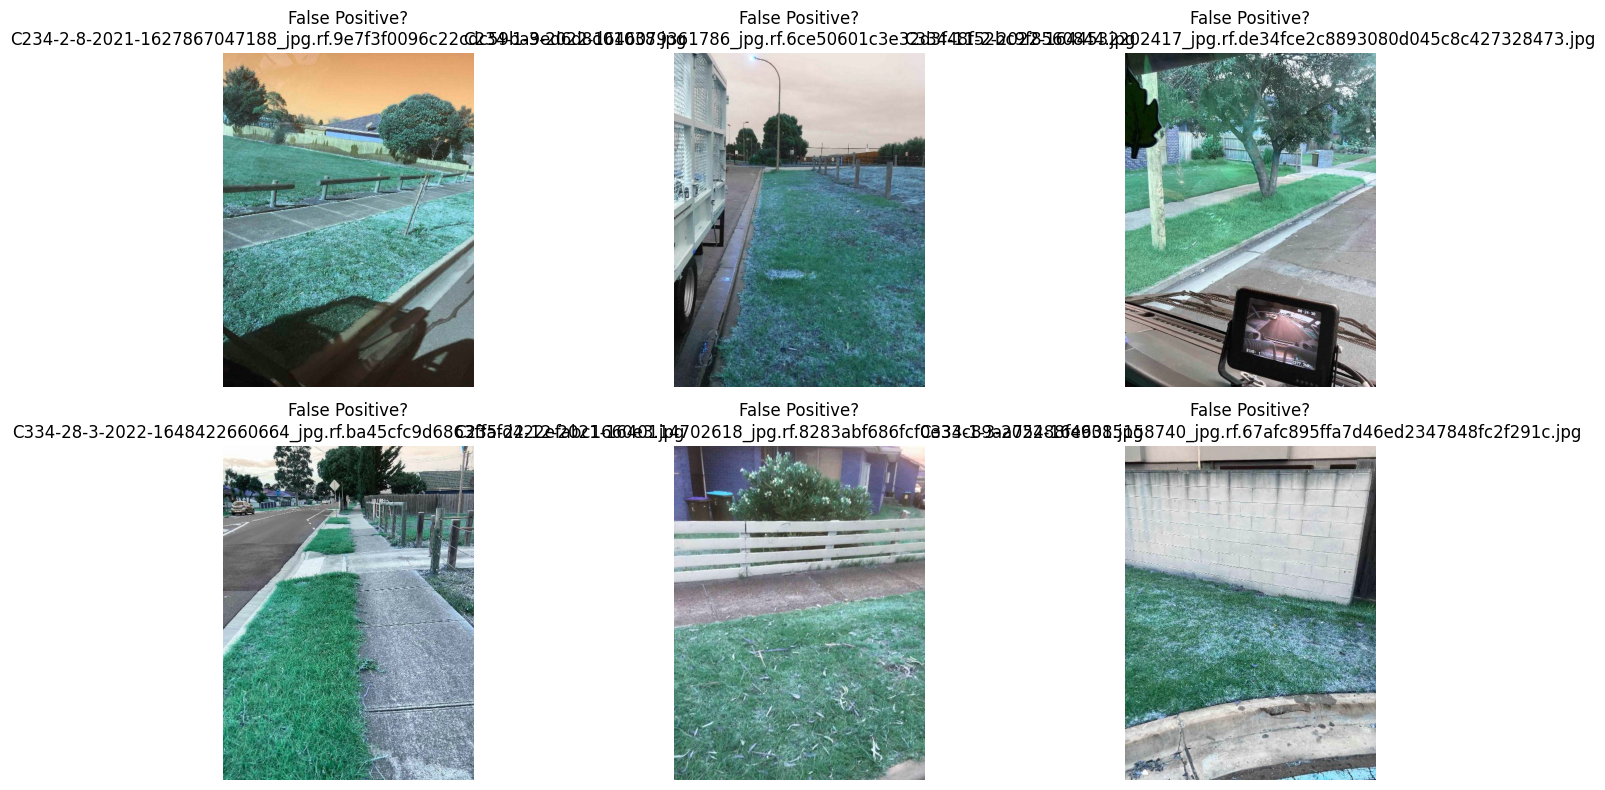

In [19]:
LABEL_DIR = WORK_DATASET_DIR / "valid" / "labels"

false_positive_imgs = []

for img_path in all_images:
    label_path = LABEL_DIR / f"{img_path.stem}.txt"

    # nếu label rỗng (no rubbish)
    if label_path.exists() and label_path.stat().st_size == 0:
        false_positive_imgs.append(img_path)

print("No-rubbish images:", len(false_positive_imgs))

# lấy random vài ảnh
sample_fp = random.sample(false_positive_imgs, min(6, len(false_positive_imgs)))

results = best_model.predict(
    source=[str(p) for p in sample_fp],
    conf=0.35,
    save=False,
    device=0
)

plt.figure(figsize=(15, 8))

for i, (img_path, res) in enumerate(zip(sample_fp, results)):
    pred_img = res.plot()

    plt.subplot(2, 3, i+1)
    plt.imshow(pred_img)
    plt.title(f"False Positive?\n{img_path.name}")
    plt.axis("off")

plt.tight_layout()
plt.show()